# Sentiment Analysis Using NLP

## EncoderX Remote Internship – AI/ML Batch 02

### Week 02 – Task 02

This project implements a Natural Language Processing (NLP) based
sentiment analysis system using the IMDb Movie Reviews dataset.

The objective is to classify movie reviews as positive or negative.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/IMDB_Dataset.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Total reviews:", len(df))

df.head()

Dataset loaded successfully!
Total reviews: 38816


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [ ]:
print(df["sentiment"].value_counts())

sentiment
positive    19419
negative    19397
Name: count, dtype: int64


In [ ]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenization
    words = text.split()

    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df["clean_review"] = df["review"].apply(preprocess_text)

print(df[["review", "clean_review", "sentiment"]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review sentiment  
0  one reviewer mentioned watching oz episode hoo...  positive  
1  wonderful little production filming technique ...  positive  
2  thought wonderful way spend time hot summer we...  positive  
3  basically family little boy jake think zombie ...  negative  
4  petter mattei love time money visually stunnin...  positive  


In [ ]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31052
Testing samples: 7764


In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature extraction completed!")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

TF-IDF feature extraction completed!
Training feature shape: (31052, 20000)
Testing feature shape: (7764, 20000)


In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="positive"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="positive"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="positive"
)

print("Model Evaluation Results")
print("-------------------------")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Evaluation Results
-------------------------
Accuracy :  0.8925
Precision: 0.8826
Recall   : 0.9055
F1-Score : 0.8939


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      3880
    Positive       0.88      0.91      0.89      3884

    accuracy                           0.89      7764
   macro avg       0.89      0.89      0.89      7764
weighted avg       0.89      0.89      0.89      7764



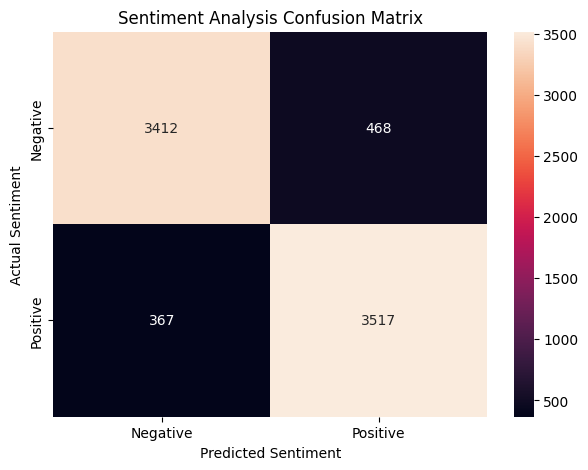

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [ ]:
def predict_sentiment(review):

    cleaned_review = preprocess_text(review)

    review_tfidf = tfidf.transform([cleaned_review])

    prediction = model.predict(review_tfidf)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [ ]:
review1 = "This movie was absolutely amazing and I really enjoyed it."

review2 = "The movie was boring and disappointing."

print("Review 1:", predict_sentiment(review1))
print("Review 2:", predict_sentiment(review2))

Review 1: Negative
Review 2: Negative


In [28]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


## Results Analysis

The Logistic Regression model was trained to classify IMDb movie reviews
as positive or negative using TF-IDF features.

The model achieved an accuracy of **89.25%**.

The precision was **88.26%**, recall was
**90.55%**, and the F1-score was
**89.39%**.

The results indicate that TF-IDF combined with Logistic Regression
can effectively identify sentiment from movie reviews.

## Strengths

- Simple and efficient NLP classification approach.
- TF-IDF converts text into useful numerical features.
- Logistic Regression performs well for text classification.
- The preprocessing workflow removes unnecessary text noise.

## Weaknesses

- The model may struggle with sarcasm and complex language.
- Context and word order are not fully understood.
- Some reviews may contain mixed positive and negative opinions.

## Practical Applications

The sentiment analysis system can be applied to:

- Customer feedback analysis
- Product review analysis
- Marketing analysis
- Customer support
- Social media feedback

## Possible Improvements

Future improvements could include:

- Using word embeddings.
- Using LSTM or BERT-based models.
- Hyperparameter tuning.
- Using a larger or more diverse dataset.
- Improving text preprocessing.
- Handling sarcasm and context more effectively.

## Conclusion

This project demonstrates a complete NLP workflow from text preprocessing
and feature extraction to sentiment classification and evaluation.

The model successfully classifies movie reviews into positive and negative
sentiments and provides a foundation for practical sentiment analysis
applications.